In [38]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [21]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training images:", X_train.shape)
print("Training labels:", y_train.shape)
print("Testing images:", X_test.shape)
print("Testing labels:", y_test.shape)

Training images: (60000, 28, 28)
Training labels: (60000,)
Testing images: (10000, 28, 28)
Testing labels: (10000,)


In [22]:
X_train = X_train / 255.0
X_test = X_test / 255.0

print("Minimum pixel value:", X_train.min())
print("Maximum pixel value:", X_train.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


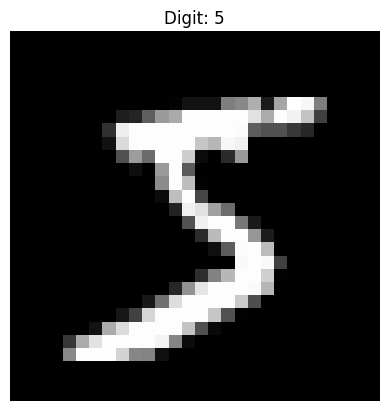

In [23]:
plt.imshow(X_train[0], cmap="gray")
plt.title(f"Digit: {y_train[0]}")
plt.axis("off")
plt.show()

In [24]:
X_train = X_train.reshape(60000, 784)
X_test = X_test.reshape(10000, 784)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (60000, 784)
Testing shape: (10000, 784)


In [25]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=(784,)),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                      │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [27]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9191 - loss: 0.2805 - val_accuracy: 0.9647 - val_loss: 0.1347
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9635 - loss: 0.1231 - val_accuracy: 0.9727 - val_loss: 0.0926
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9749 - loss: 0.0843 - val_accuracy: 0.9782 - val_loss: 0.0796
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9811 - loss: 0.0625 - val_accuracy: 0.9765 - val_loss: 0.0770
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9851 - loss: 0.0480 - val_accuracy: 0.9775 - val_loss: 0.0785


In [28]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9765 - loss: 0.0803
Test Accuracy: 0.9764999747276306
Test Loss: 0.08033424615859985


In [29]:
predictions = model.predict(X_test)

predicted_digits = np.argmax(predictions, axis=1)

print("Predicted:", predicted_digits[:10])
print("Actual:   ", y_test[:10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Predicted: [7 2 1 0 4 1 4 9 6 9]
Actual:    [7 2 1 0 4 1 4 9 5 9]


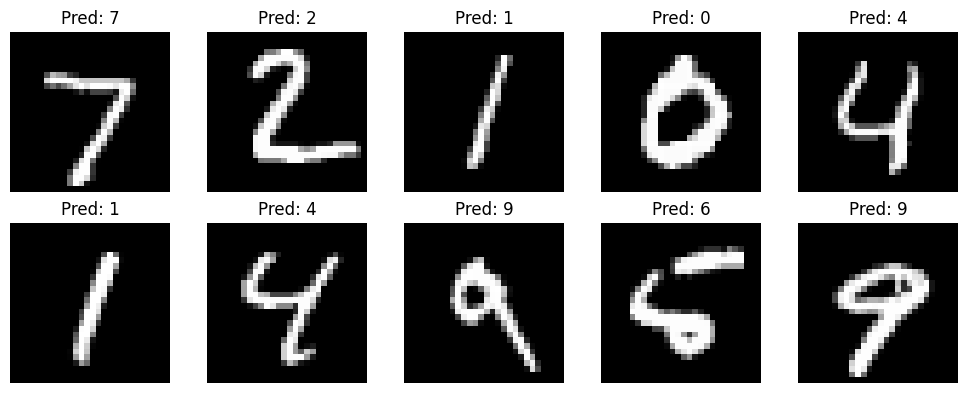

In [30]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[i].reshape(28, 28), cmap="gray")
    plt.title(f"Pred: {predicted_digits[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [31]:
wrong_predictions = np.where(predicted_digits != y_test)[0]

print("Incorrect predictions:", len(wrong_predictions))

Incorrect predictions: 235


In [33]:
from sklearn.metrics import confusion_matrix

In [34]:
cm = confusion_matrix(y_test, predicted_digits)

print(cm)

[[ 968    0    2    2    0    3    3    1    1    0]
 [   0 1122    6    0    0    1    4    1    1    0]
 [   3    0 1014    1    1    0    3    5    5    0]
 [   0    0    8  990    0    4    0    4    2    2]
 [   1    0    4    0  963    0    5    3    0    6]
 [   3    0    0    8    1  871    5    0    2    2]
 [   4    1    1    1    2    5  943    0    1    0]
 [   2    5   11    1    3    0    0  999    1    6]
 [   4    0    5   10    4   16    3    4  925    3]
 [   2    5    0    9   12    4    0    6    1  970]]


In [39]:
%pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [40]:

import seaborn as sns
import matplotlib.pyplot as plt

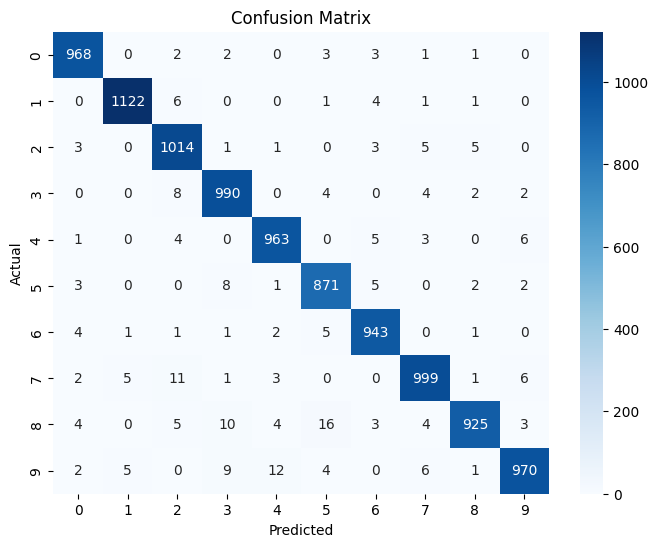

In [41]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [43]:
from sklearn.metrics import accuracy_score

In [45]:
y_pred = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [47]:
import numpy as np

y_pred_labels = np.argmax(y_pred, axis=1)

In [48]:
print("Model Accuracy:", accuracy_score(y_test, y_pred_labels))

Model Accuracy: 0.9765


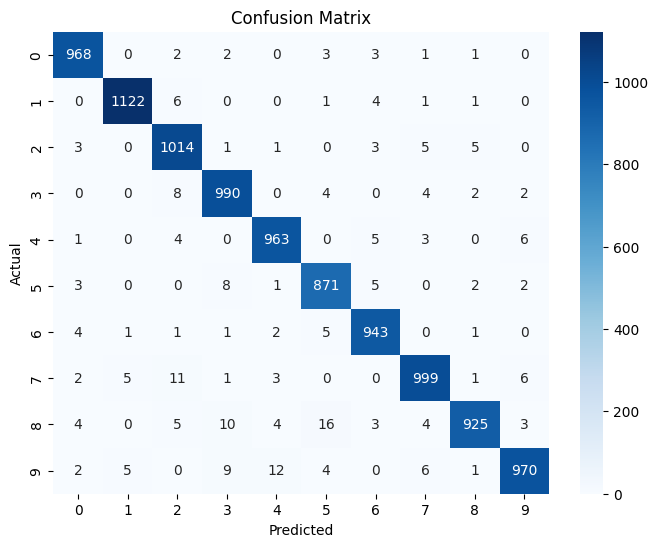

In [49]:
cm = confusion_matrix(y_test, y_pred_labels)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [50]:
import joblib

joblib.dump(model, "mnist_model.pkl")

['mnist_model.pkl']

In [51]:
import os

print(os.path.exists("mnist_model.pkl"))

True


In [52]:
import joblib

loaded_model = joblib.load("mnist_model.pkl")

print("Model loaded successfully!")

Model loaded successfully!


In [54]:
y_pred_new = loaded_model.predict(X_test)
y_pred_new_labels = np.argmax(y_pred_new, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [55]:
print("Saved Model Accuracy:", accuracy_score(y_test, y_pred_new_labels))

Saved Model Accuracy: 0.9765


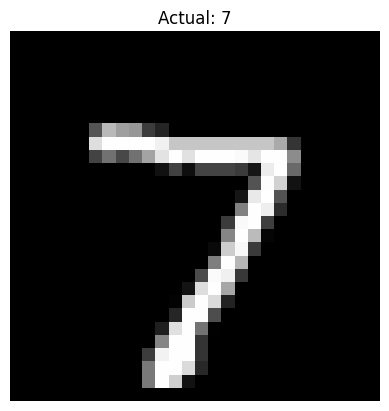

In [56]:
import matplotlib.pyplot as plt
import numpy as np

index = 0

plt.imshow(X_test[index].reshape(28, 28), cmap="gray")
plt.title(f"Actual: {y_test.iloc[index] if hasattr(y_test, 'iloc') else y_test[index]}")
plt.axis("off")
plt.show()

In [57]:
prediction = y_pred_new_labels[index]

print("Predicted Digit:", prediction)

Predicted Digit: 7
